In [24]:
import os, json, pickle
import numpy as np
import torch
from torch.utils.data import DataLoader
from go_ml.data_utils import *

train_path = "/home/andrew/cafa5_team/data/"
with open(f"{train_path}/cafa_dataset/go_terms.json", "r") as f:
    go_terms = json.load(f)
with open(f"{train_path}/cafa_dataset/prot_ids.json", "r") as f:
    prot_ids = json.load(f)
with open(f"{train_path}/cafa_dataset/rev_annot.pkl", "rb") as f:
    labels = pickle.load(f)
print((np.asarray(labels.sum(axis=1)) > 0).sum() / labels.shape[0])
prot_sequences, seq_ids = load_protein_sequences(f"{train_path}/uniprot_sprot.fasta")

assert all(s1 == s2 for s1, s2 in zip(prot_ids, seq_ids))
labeled_id = (np.asarray(labels.sum(axis=1)) > 0).flatten()

gen = np.random.default_rng(seed=42)
ind = gen.permuted(np.arange(len(prot_ids))[labeled_id])
train_len = ind.shape[0] * 4 // 5
train_ind = ind[:train_len]
val_ind = ind[train_len:]
np.sort(train_ind); np.sort(val_ind)
train_ids = [prot_ids[i] for i in train_ind]; train_sequences = [prot_sequences[i] for i in train_ind]
val_ids = [prot_ids[i] for i in val_ind]; val_sequences = [prot_sequences[i] for i in val_ind]
train_labels = labels[train_ind, :]; val_labels = labels[val_ind, :]
train_dataset = BertSeqDataset(train_ids, go_terms, train_sequences, train_labels)
val_dataset = BertSeqDataset(val_ids, go_terms, val_sequences, val_labels)
print(f"train len {len(train_dataset)} val len {len(val_dataset)}")

# from Bio import SeqIO
# from Bio.Seq import Seq
# from Bio.SeqRecord import SeqRecord

# train_seq = [SeqRecord(Seq(seq.upper()), id=prot_id) for seq, prot_id in zip(train_sequences, train_ids)]
# with open("../../data/train_seq.fasta", "w") as f:
#     SeqIO.write(train_seq, f, 'fasta')

0.27317815417177815
train len 124524 val len 31131


In [14]:
import pandas as pd
train_similarity = pd.read_csv("../../data/dblast_data/train_crossmatches.tsv", sep='\t', header=None)

,0,1,2,3,4,5,6,7,8,9,10,11
0,Q934G3,Q934G3,100.0,236,0,0,1,236,1,236,5.020000e-173,476.0
1,Q934G3,P0A1U8,40.2,224,123,8,13,236,15,227,8.880000e-38,133.0
2,Q9H2W6,Q9H2W6,100.0,279,0,0,1,279,1,279,2.600000e-201,551.0
3,Q9H2W6,Q5RBU2,96.8,279,9,0,1,279,1,279,1.550000e-193,532.0
4,Q9H2W6,Q5RK00,81.0,279,51,1,1,279,1,277,1.500000e-163,456.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1768475,P23290,P35802,37.9,280,128,6,2,277,13,250,4.120000e-55,181.0
1768476,P23290,Q812E9,38.2,280,127,6,2,277,13,250,4.120000e-55,181.0
1768477,P23290,Q0VD07,38.2,280,127,6,2,277,13,250,5.810000e-55,180.0
1768478,P23290,P51674,38.2,280,127,6,2,277,13,250,5.810000e-55,180.0


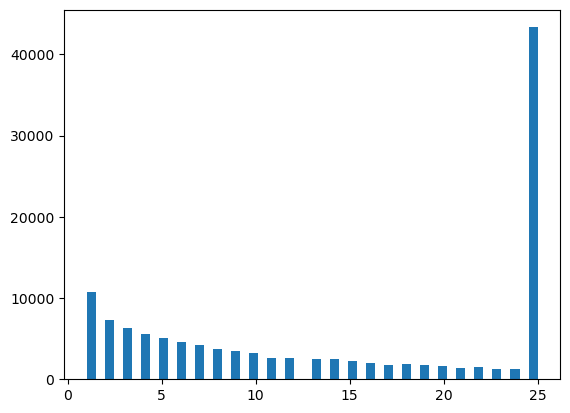

In [18]:
from collections import Counter
hit_num = Counter(train_similarity[train_similarity[10] < 0.01][0])
import matplotlib.pyplot as plt
plt.hist(hit_num.values(), bins=50)
plt.show()

In [30]:
train_cluster = pd.read_csv("../../data/dblast_data/train_cluster.tsv", sep='\t')
from collections import Counter
cluster_sizes = Counter(train_cluster['centroid'])
# import matplotlib.pyplot as plt
# plt.hist(cluster_sizes.values(), bins=50)
# plt.show()
max_cluster_pid, mc_size = cluster_sizes.most_common(10)[0]

In [33]:
max_cluster

,centroid,member
119211,Q8NHC5,Q8NGY5
119212,Q8NHC5,Q8VEW2
119213,Q8NHC5,A4D2G3
119214,Q8NHC5,Q8NGA6
119215,Q8NHC5,O76100
...,...,...
119638,Q8NHC5,Q96R28
119639,Q8NHC5,Q8NGE9
119640,Q8NHC5,P47884
119641,Q8NHC5,Q8NGC7


In [35]:
max_cluster = train_cluster[train_cluster['centroid'] == max_cluster_pid]
max_pid_ind = [train_ids.index(pid) for pid in max_cluster['member']]
mc_labels = train_labels[max_pid_ind].todense()

In [49]:
counts = mc_labels.sum(axis=0)
_, nonzero_col = counts.nonzero()
nonzero_counts = counts[0, nonzero_col]

In [52]:
nonzero_counts

matrix([[  1,  16, 242, 296,   2,   2,   1,   1, 428,   3, 181,   1, 304,
         121, 297,   4, 297,   5,   1,   1,   1,   2,   1,   2,   1,   1,
         121,   2,   1,   2,   2,   1,   1, 428,   1,   2,   2, 141,   2,
         118, 428,   1,   1,   2,   1, 428,   2,   2,   1,   2,   2,   2,
           1,   2,   1, 154,   1,   2,   2,   4,   2,   2,   5,   2,   2,
           1,   2,   1,   1,   2,   2,   2,   1,   1,   2,   1, 145,   1,
           2,   3,   1,   2,   1,   2,   2,   1,   1,   1,   2,   2,   2,
           2,   1,   2,   1,   2,   1,   1,   3,   1,   2,   3,   2,   1,
         146,   2,   2,   2,   1,   1,   2,   4,   1,   1,   1,   1,   5,
           1,   1,   3,   2,   4,   2,   1,   1,   4,   1, 119,   4,   2,
           1,   2,   1,   2,   2,   2, 119,   1,   1,   2,   1,   2,   1,
           1,   3, 145,   1,   2,   4,   4,   4,   1,   2,   2,   1,   1,
           1,   1,   2,   2,   1, 146,   2,   2,   1,   2,   2,   1,   1,
         119,   1,   1,   1, 119,   1,

(37708,)